In [2]:
# 0. 라이브러리 로드

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('✅ 라이브러리 로드 완료')

✅ 라이브러리 로드 완료


In [9]:
# 1. 데이터 로드 (xlsx 파일)
df = pd.read_excel('../data/Ecommerce_Dataset.xlsx', sheet_name='E Comm')

print(f'📊 데이터 크기: {df.shape[0]:,}행 x {df.shape[1]}열')
df.head()

📊 데이터 크기: 5,630행 x 20열


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [10]:
# 2. 기본 정보 확인 (결측치 + dtype)
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count': df.isnull().sum(),
    'null_%': (df.isnull().sum() / len(df) * 100).round(2)
})

print('=== 결측치 있는 컬럼 ===')
display(info_df[info_df['null_count'] > 0])
print(f'\n중복 행: {df.duplicated().sum()}개')

=== 결측치 있는 컬럼 ===


,dtype,null_count,null_%
Tenure,float64,264,4.69
WarehouseToHome,float64,251,4.46
HourSpendOnApp,float64,255,4.53
OrderAmountHikeFromlastYear,float64,265,4.71
CouponUsed,float64,256,4.55
OrderCount,float64,258,4.58
DaySinceLastOrder,float64,307,5.45



중복 행: 0개


In [11]:
# 3. 기술통계
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,5630.0,52815.500000,1625.385339,50001.0,51408.25,52815.50,54222.7500,55630.00
Churn,5630.0,0.168384,0.374240,0.0,0.00,0.00,0.0000,1.00
Tenure,5366.0,10.189899,8.557241,0.0,2.00,9.00,16.0000,61.00
CityTier,5630.0,1.654707,0.915389,1.0,1.00,1.00,3.0000,3.00
WarehouseToHome,5379.0,15.639896,8.531475,5.0,9.00,14.00,20.0000,127.00
HourSpendOnApp,5375.0,2.931535,0.721926,0.0,2.00,3.00,3.0000,5.00
NumberOfDeviceRegistered,5630.0,3.688988,1.023999,1.0,3.00,4.00,4.0000,6.00
SatisfactionScore,5630.0,3.066785,1.380194,1.0,2.00,3.00,4.0000,5.00
NumberOfAddress,5630.0,4.214032,2.583586,1.0,2.00,3.00,6.0000,22.00
Complain,5630.0,0.284902,0.451408,0.0,0.00,0.00,1.0000,1.00


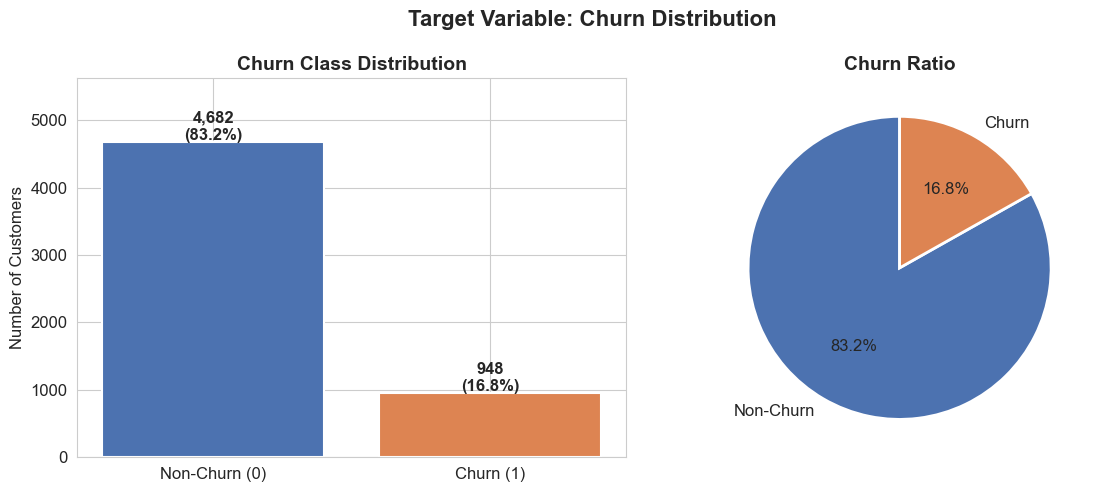

Imbalance ratio: 4.9:1 (Non-Churn:Churn)


In [13]:
# 4. 타겟 변수 분포 (클래스 불균형 확인)
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#4C72B0', '#DD8452']

# 막대 그래프
axes[0].bar(['Non-Churn (0)', 'Churn (1)'], churn_counts.values,
            color=colors, edgecolor='white', linewidth=1.5)
for i, (count, pct) in enumerate(zip(churn_counts.values, churn_pct.values)):
    axes[0].text(i, count + 30, f'{count:,}\n({pct:.1f}%)',
                 ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Churn Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, churn_counts.max() * 1.2)

# 파이 차트
axes[1].pie(churn_counts.values, labels=['Non-Churn', 'Churn'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Ratio', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: Churn Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Imbalance ratio: {churn_counts[0]/churn_counts[1]:.1f}:1 (Non-Churn:Churn)')

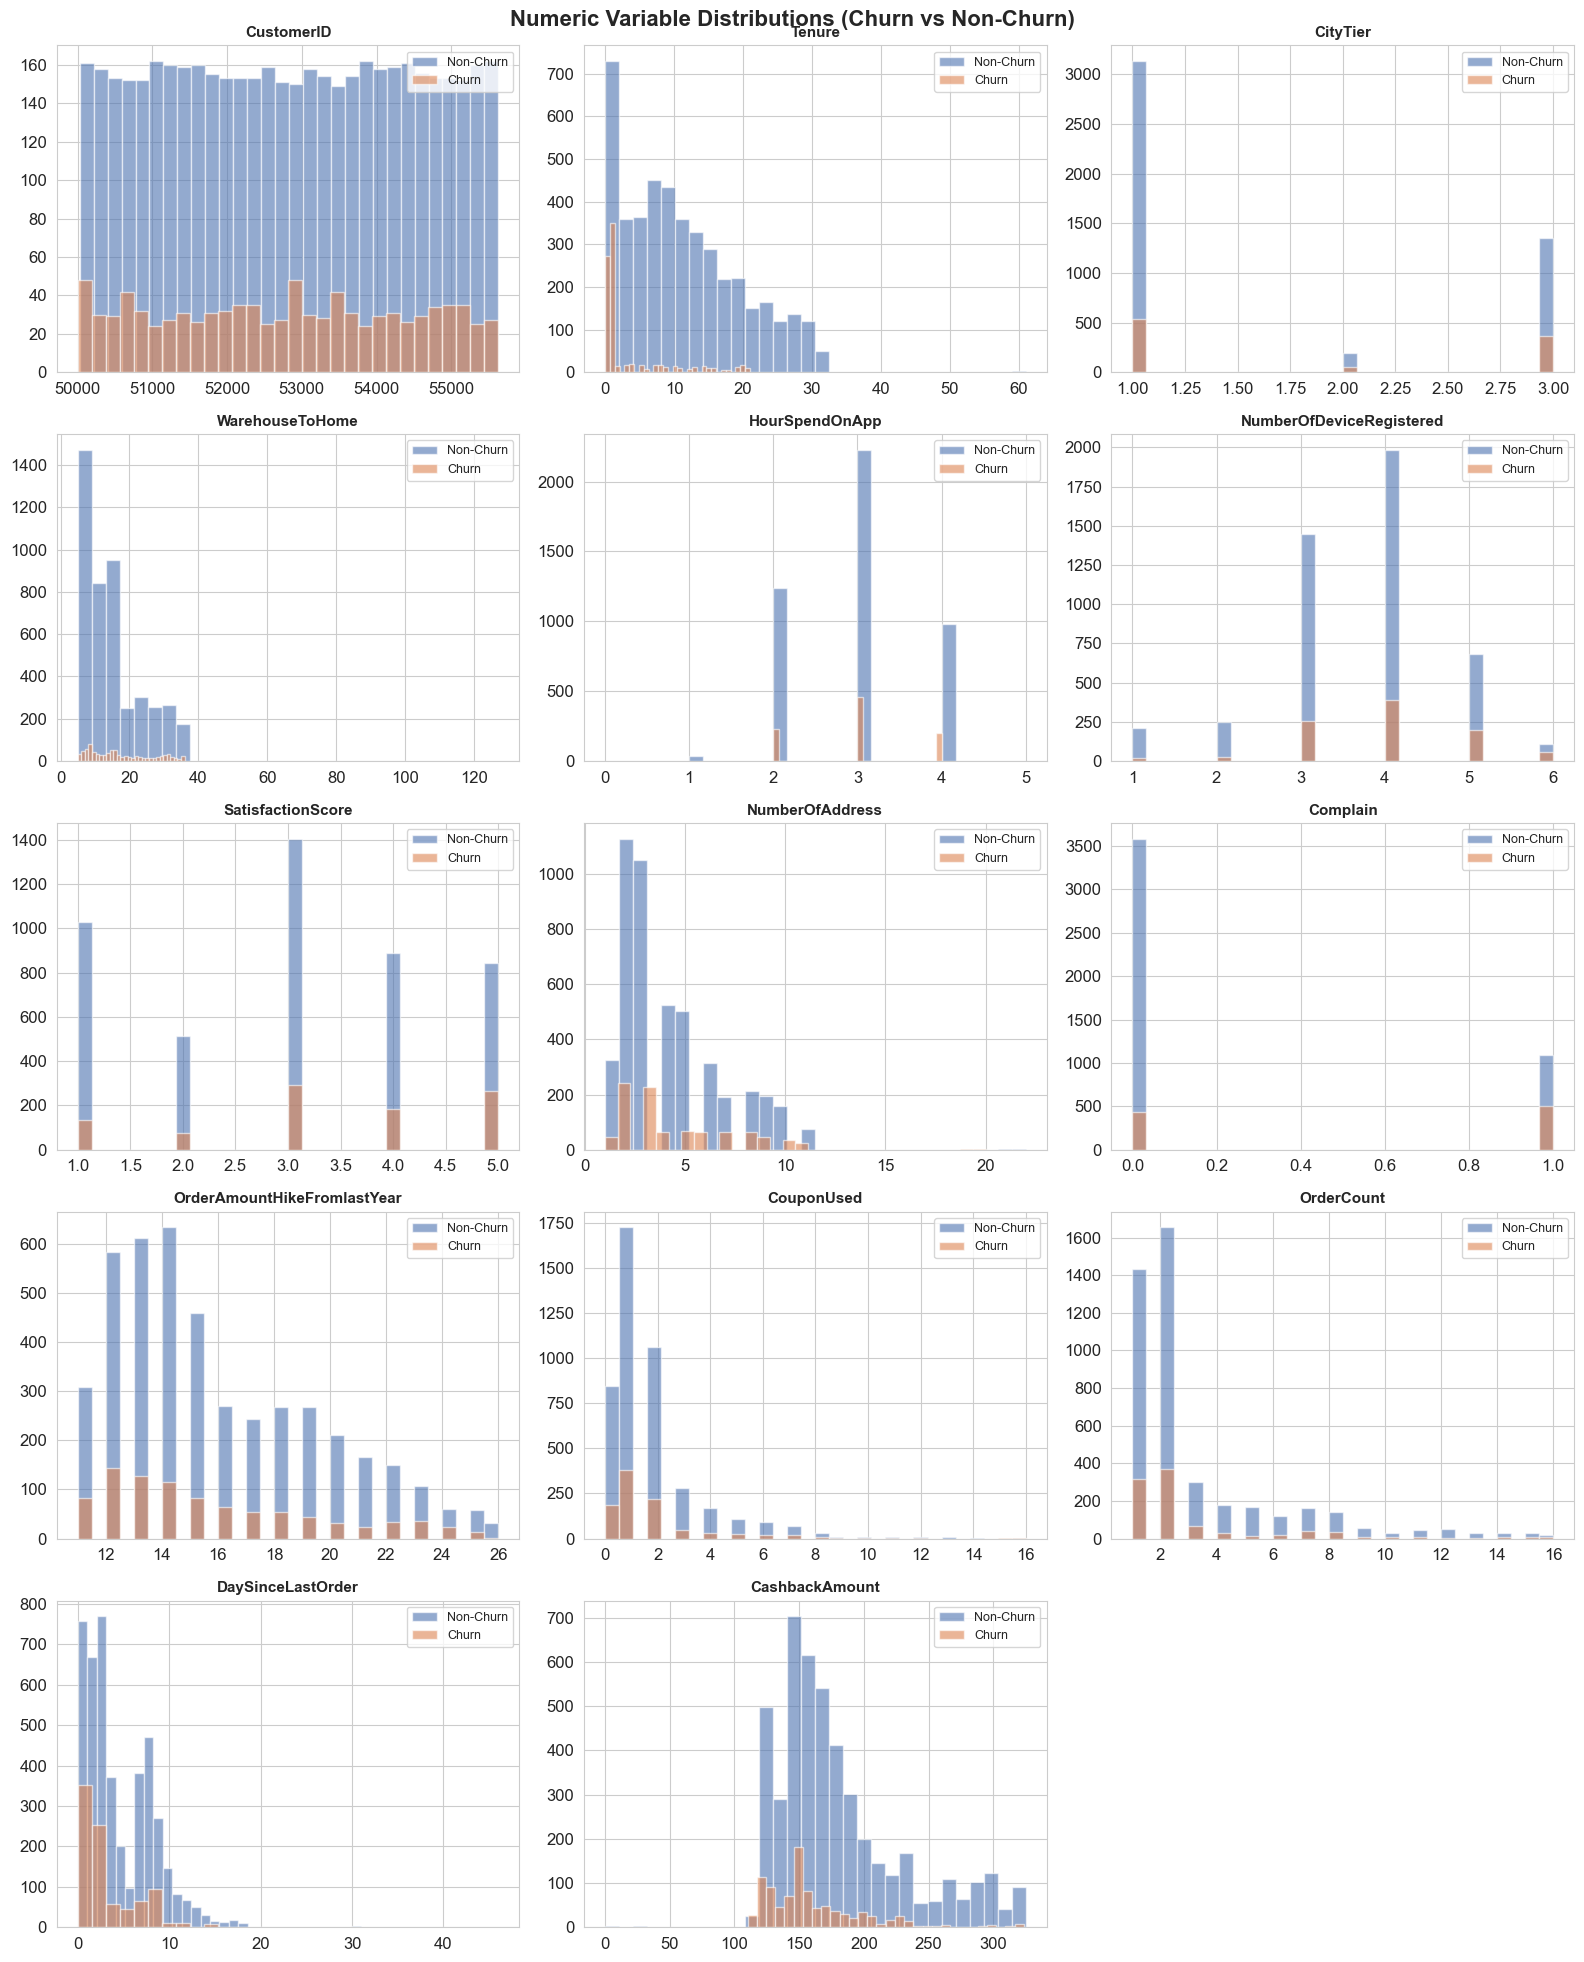

In [16]:
# 5. 수치형 변수 분포 (이탈 vs 비이탈)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'Churn']

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for churn_val, color, label in [(0, '#4C72B0', 'Non-Churn'), (1, '#DD8452', 'Churn')]:
        axes[i].hist(df[df['Churn'] == churn_val][col].dropna(),
            bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Variable Distributions (Churn vs Non-Churn)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/01_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

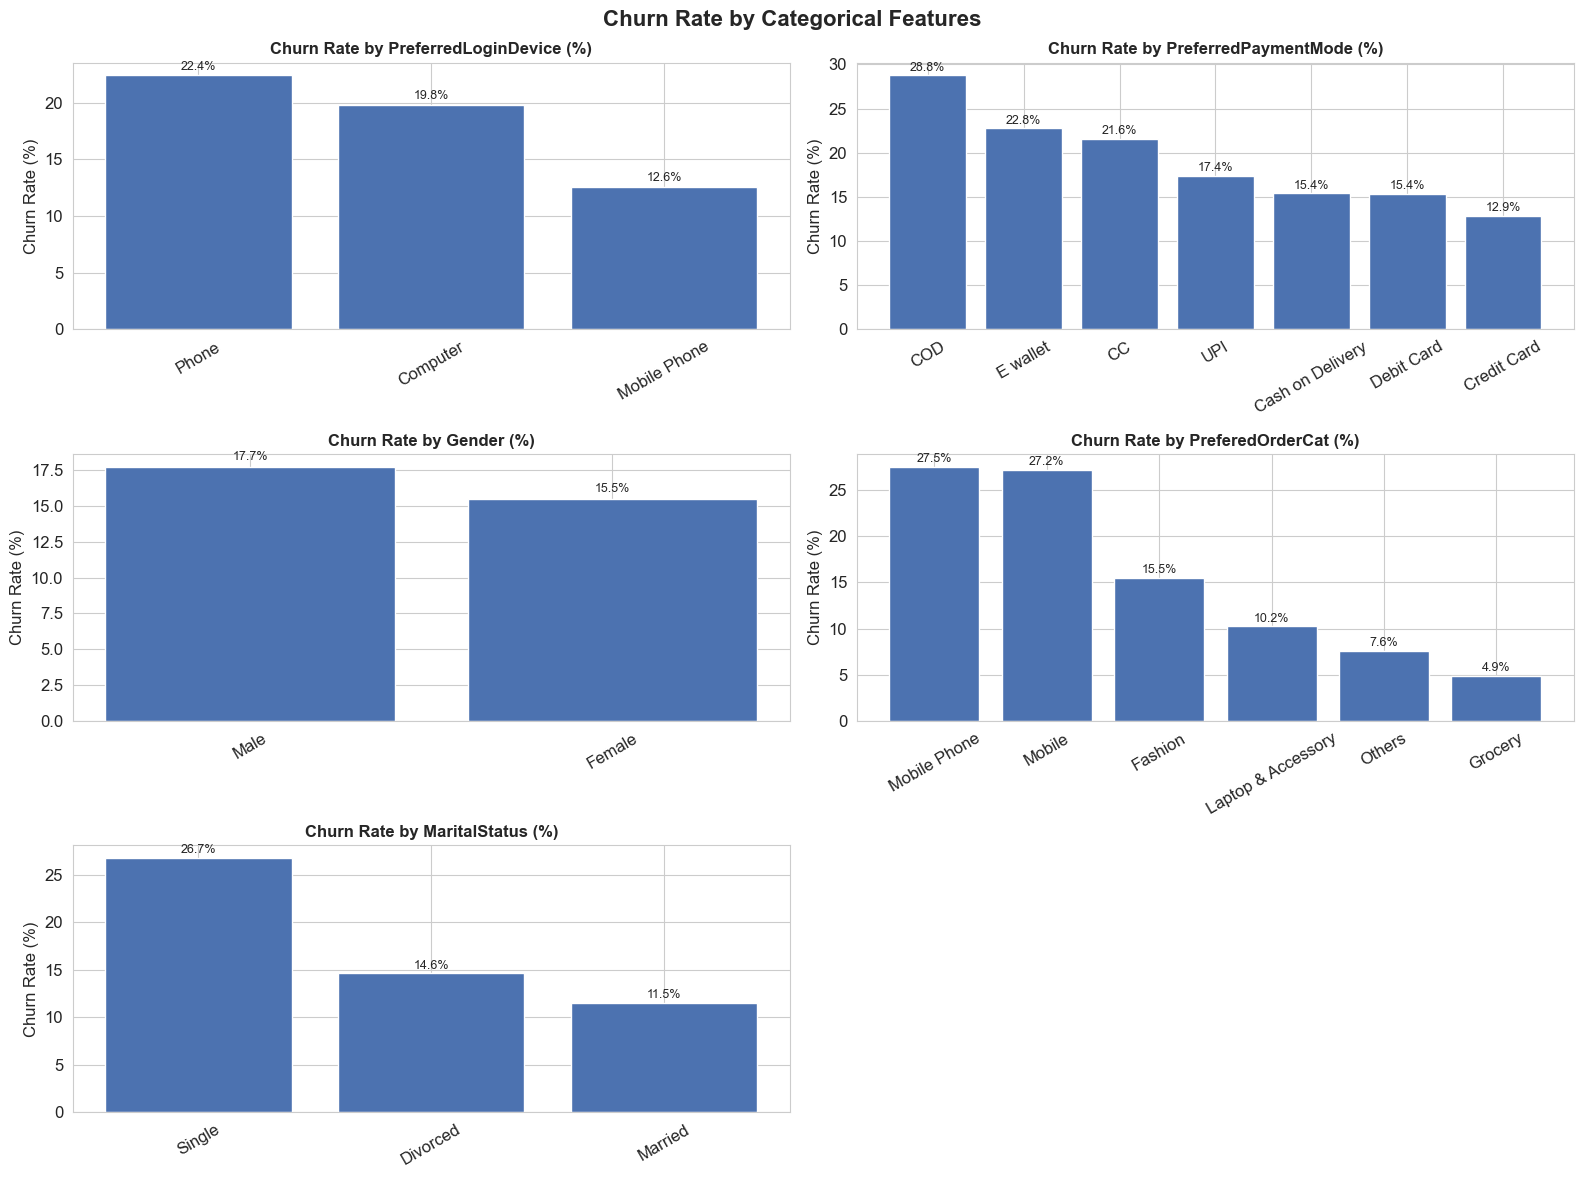

In [17]:
# 6. 범주형 변수별 이탈률
cat_cols = df.select_dtypes(include='object').columns.tolist()

n_cols = 2
n_rows = (len(cat_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False) * 100
    bars = axes[i].bar(churn_rate.index, churn_rate.values, color='#4C72B0', edgecolor='white')
    axes[i].set_title(f'Churn Rate by {col} (%)', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{bar.get_height():.1f}%', ha='center', fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate by Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/01_categorical_churnrate.png', dpi=150, bbox_inches='tight')
plt.show()

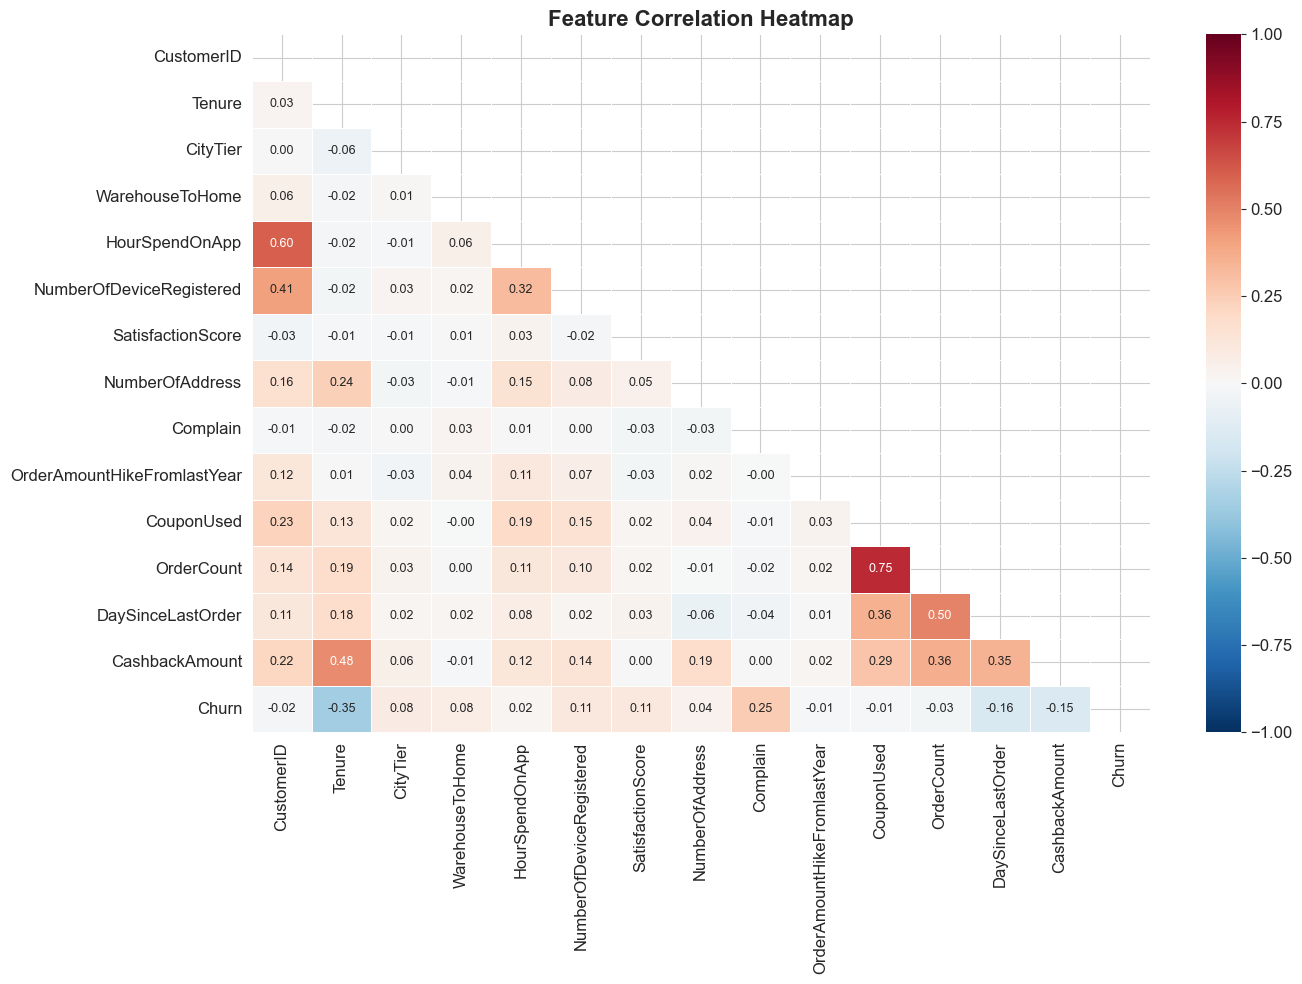


=== Top 5 Features Correlated with Churn ===
Tenure                      0.349408
Complain                    0.250188
DaySinceLastOrder           0.160757
CashbackAmount              0.154118
NumberOfDeviceRegistered    0.107939
Name: Churn, dtype: float64


In [18]:
# 7. 상관관계 히트맵
corr = df[num_cols + ['Churn']].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/01_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Top 5 Features Correlated with Churn ===')
print(corr['Churn'].drop('Churn').abs().sort_values(ascending=False).head(5))

In [19]:
# 8. EDA 요약
print('=' * 55)
print('📋 EDA 요약')
print('=' * 55)
print(f'  총 데이터       : {df.shape[0]:,}행 x {df.shape[1]}열')
print(f'  결측치 컬럼     : {(df.isnull().sum() > 0).sum()}개')
print(f'  중복 행         : {df.duplicated().sum()}개')
print(f'  이탈 비율       : {df["Churn"].mean()*100:.1f}%  →  클래스 불균형 존재')
print()
print('➡️  다음 단계: 02_preprocessing.ipynb')
print('   - 결측치 대체 (Iterative Imputer / Median)')
print('   - 이상치 제거 (Mahalanobis Distance, p < 0.001)')
print('   - One-Hot Encoding')
print('   - Train/Test Split (80:20, stratified)')

📋 EDA 요약
  총 데이터       : 5,630행 x 20열
  결측치 컬럼     : 7개
  중복 행         : 0개
  이탈 비율       : 16.8%  →  클래스 불균형 존재

➡️  다음 단계: 02_preprocessing.ipynb
   - 결측치 대체 (Iterative Imputer / Median)
   - 이상치 제거 (Mahalanobis Distance, p < 0.001)
   - One-Hot Encoding
   - Train/Test Split (80:20, stratified)
